In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

from models.multi_mlp import simple_FC, JointMLP

import numpy as np
import pandas as pd
import copy
import datetime

from sklearn.metrics import roc_curve, auc, confusion_matrix

import matplotlib.pyplot as plt

## Example of a forward pass on fake data

In [2]:
# two arbitrary views, one with 1000 features, and another with 500 features
marg_model1 = simple_FC(input_size=1000, hidden_sizes=[128, 64], prediction_dim=10)
marg_model2 = simple_FC(input_size=500, hidden_sizes=[64, 64], prediction_dim=10)

# joint model
joint_model = JointMLP(marginal_models=[marg_model1, marg_model2], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-3)

In [3]:
# fake inputs/targets
example_input1 = torch.randn(100, 1000)
example_input2 = torch.randn(100, 500)
example_target = torch.randint(0, 10, (100,))

In [4]:
# get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
yhat, h, yhats, hiddens = joint_model([example_input1, example_input2])

In [5]:
# pass the predictions and distributions to the loss function and update parameters
loss = joint_model.loss(example_target, yhat, yhats)
loss.backward()

## Example with real data

In [115]:
proData = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_proteins_luke.csv')
lipData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/ICL104_lipids_aligned_for_stats.xlsx")
metabData = pd.read_excel("/Volumes/Data_Harmony/DHS_Omics/ICL04/OMICS_ICL104_Metabolomics_YMK.xlsx")
metabData = metabData.drop(columns=['KEGG', 'CAS', 'PubChem'])

fmeta = pd.read_csv('~/Documents/Data/example_omicsdata/multi-omics-from-share/ICL104_Pep_Prot_Lipid_Metab/ICL104_fmeta.csv')

In [108]:
# some samples missing from some datasets.
lipData.shape, metabData.shape, proData.shape

((250, 61), (138, 61), (2853, 61))

In [109]:
# filter all rows in fmeta where any of SampleID_proteomics, SampleID_proteomics, SampleID_metab are NA
fmeta = fmeta[~fmeta[['SampleID_proteomics', 'SampleID_lipidpos', 'SampleID_metab']].isna().any(axis=1)]
fmeta['Virus_y'] = fmeta.Virus.replace({'Cal[0-9]*': 'Cal'}, regex=True)
y = fmeta.Virus_y

In [119]:
# make the "LIPID" column in lipData the index
lipData = lipData.set_index('Name')
metabData = metabData.set_index('Metabolite')
proData = proData.set_index('Protein')

# replace zeros with NA
lipData[lipData == 0] = np.nan
metabData[metabData == 0] = np.nan

# log2 transform the data and column-wise median center
lipData = np.log2(lipData)
metabData = np.log2(metabData)
# proData = np.log2(proData) # don't if already log2

lipData = lipData - lipData.median(axis=0)
metabData = metabData - metabData.median(axis=0)
proData = proData - proData.median(axis=0)

# [0, 1] normalize all the data
lipData = (lipData - np.min(lipData)) / (np.max(lipData) - np.min(lipData))
metabData = (metabData - np.min(metabData)) / (np.max(metabData) - np.min(metabData))
proData = (proData - np.min(proData)) / (np.max(proData) - np.min(proData))

In [120]:
# columns are nicely aligned
y = pd.Series(['Cal' if 'Cal04' in el else 'Mock' for el in lipData.columns])

In [121]:
# drop indices with all null values
lip_inds = (lipData.isnull() == False).sum(axis = 1) > 0
metab_inds = (metabData.isnull() == False).sum(axis = 1) > 0
pro_inds = (proData.isnull() == False).sum(axis = 1) > 0

lipData = lipData[lip_inds]
metabData = metabData[metab_inds]
proData = proData[pro_inds]

# impute the datasets with the row means
lipData = lipData.apply(lambda row: row.fillna(row.mean()), axis=1)
metabData = metabData.apply(lambda row: row.fillna(row.mean()), axis=1)
proData = proData.apply(lambda row: row.fillna(row.mean()), axis=1)

In [10]:
# Use this if our column names are aligned with f_meta, otherwise make sure to manually check that they align
# lipData = lipData.loc[:,lipData.columns.isin(fmeta['SampleID_lipidpos'])]
# metabData = metabData.loc[:,metabData.columns.isin(fmeta['SampleID_metab'])]
# proData = proData.loc[:,proData.columns.isin(fmeta['SampleID_proteomics'])]

In [123]:
np.random.seed(1565)
cal_inds = np.random.choice(np.where(y == 'Cal')[0], int(np.sum(y == 'Cal') * 0.2))
mock_inds = np.random.choice(np.where(y == 'Mock')[0], int(np.sum(y == 'Mock') * 0.2))
test_inds = np.concatenate([cal_inds, mock_inds])

train_inds = np.isin(np.arange(y.shape[0]), test_inds) == False

train_lip = lipData.iloc[:,train_inds]
train_pro = proData.iloc[:,train_inds]
train_metab = metabData.iloc[:,train_inds]

test_lip = lipData.iloc[:, test_inds]
test_pro = proData.iloc[:, test_inds]
test_metab = metabData.iloc[:, test_inds]

ytrain = y.iloc[train_inds]
ytest = y.iloc[test_inds]

### Construct the Model

In [124]:
# three view-specific encoders with the appropriate input size:

# the last hidden size must be the same since we are averaging
last_hidden_size = 64

lip_marg = simple_FC(input_size=train_lip.shape[0], hidden_sizes=[128, last_hidden_size], prediction_dim=y.nunique())
metab_marg = simple_FC(input_size=train_metab.shape[0], hidden_sizes=[64, last_hidden_size], prediction_dim=y.nunique())
pro_marg = simple_FC(input_size=train_pro.shape[0], hidden_sizes=[256, last_hidden_size], prediction_dim=y.nunique())

# joint model
joint_model = JointMLP(marginal_models=[lip_marg, metab_marg, pro_marg], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-4)

In [125]:
# turn data into tensors
lip_tensor = torch.tensor(train_lip.T.values, dtype=torch.float32)
pro_tensor = torch.tensor(train_pro.T.values, dtype=torch.float32)
metab_tensor = torch.tensor(train_metab.T.values, dtype=torch.float32)

y_gt = ytrain.astype('category').cat.codes
y_gt = torch.tensor(y_gt.values, dtype=torch.int64)

for i in range(1500):

    views = [lip_tensor, metab_tensor, pro_tensor]
    
    # randomly drop an index with low probability
    if np.random.rand() < 0.1:
        idx = np.random.randint(0, len(views))
        views = [v if i != idx else None for i, v in enumerate(views)]

    # get the predictions and distribution of the joint model, and the predictions and distributions of the marginal models
    yhat, h, yhats, hiddens = joint_model(views)

    # pass the predictions and distributions to the loss function and update parameters
    loss = joint_model.loss(y_gt, yhat, yhats)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
    optimizer.step()

    print(f'Epoch {i+1} loss: {loss.item():.3f}')

Epoch 1 loss: 0.694
Epoch 2 loss: 0.702
Epoch 3 loss: 0.703
Epoch 4 loss: 0.698
Epoch 5 loss: 0.703
Epoch 6 loss: 0.701
Epoch 7 loss: 0.698
Epoch 8 loss: 0.694
Epoch 9 loss: 0.692
Epoch 10 loss: 0.694
Epoch 11 loss: 0.692
Epoch 12 loss: 0.689
Epoch 13 loss: 0.695
Epoch 14 loss: 0.695
Epoch 15 loss: 0.689
Epoch 16 loss: 0.693
Epoch 17 loss: 0.525
Epoch 18 loss: 0.689
Epoch 19 loss: 0.689
Epoch 20 loss: 0.686
Epoch 21 loss: 0.693
Epoch 22 loss: 0.695
Epoch 23 loss: 0.522
Epoch 24 loss: 0.705
Epoch 25 loss: 0.699
Epoch 26 loss: 0.698
Epoch 27 loss: 0.520
Epoch 28 loss: 0.688
Epoch 29 loss: 0.693
Epoch 30 loss: 0.691
Epoch 31 loss: 0.697
Epoch 32 loss: 0.692
Epoch 33 loss: 0.698
Epoch 34 loss: 0.694
Epoch 35 loss: 0.695
Epoch 36 loss: 0.687
Epoch 37 loss: 0.690
Epoch 38 loss: 0.691
Epoch 39 loss: 0.695
Epoch 40 loss: 0.688
Epoch 41 loss: 0.702
Epoch 42 loss: 0.702
Epoch 43 loss: 0.689
Epoch 44 loss: 0.694
Epoch 45 loss: 0.688
Epoch 46 loss: 0.692
Epoch 47 loss: 0.684
Epoch 48 loss: 0.695
E

In [126]:
# example prediction
joint_model.eval()

ytest_gt = ytest.astype('category').cat.codes

liptest_tensor = torch.tensor(test_lip.T.values, dtype=torch.float32)
protest_tensor = torch.tensor(test_pro.T.values, dtype=torch.float32)
metabtest_tensor = torch.tensor(test_metab.T.values, dtype=torch.float32)

with torch.inference_mode():
    yhat, poe_dist, yhats, dists = joint_model([liptest_tensor, metabtest_tensor, protest_tensor])

ypred = yhat.argmax(dim=1).numpy()

(ypred == ytest_gt.to_numpy()).mean()

1.0

In [127]:
confusion_matrix(ytest_gt, ypred)

array([[6, 0],
       [0, 6]])

In [128]:
# order is lip metab pro
(
    (yhats[0].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean(),
    (yhats[1].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean(),
    (yhats[2].argmax(dim=1).numpy() == ytest_gt.to_numpy()).mean()
)

(0.9166666666666666, 0.8333333333333334, 1.0)

In [33]:
pred_lip = yhats[0].argmax(dim=1).numpy()
pred_pro = yhats[1].argmax(dim=1).numpy()
pred_metab = yhats[2].argmax(dim=1).numpy()

(
    confusion_matrix(ytest_gt.to_numpy(), pred_lip),
    confusion_matrix(ytest_gt.to_numpy(), pred_pro),
    confusion_matrix(ytest_gt.to_numpy(), pred_metab)
)

(array([[5, 1],
        [1, 5]]),
 array([[6, 0],
        [3, 3]]),
 array([[5, 1],
        [0, 6]]))

# Variable Importance

## Gradient analysis

As a first pass for variable importance, I simply take the gradient of input input w.r.t. the predicted output probability of the positive class.  Essentially I am trying to determine which input biomolecules are important for the ability of the model to predict the positive class.

In [34]:
# get a single positive example (-1, the last example is positive)
liptest_pos = torch.clone(liptest_tensor[-1].unsqueeze(0))
protest_pos = torch.clone(protest_tensor[-1].unsqueeze(0))
metabtest_pos = torch.clone(metabtest_tensor[-1].unsqueeze(0))

liptest_pos.requires_grad = True
protest_pos.requires_grad = True
metabtest_pos.requires_grad = True

yhat, poe_dist, yhats, dists = joint_model([liptest_pos, metabtest_pos, protest_pos])


In [35]:
yhat[0,1].backward()

In [36]:
# get the gradients and multiply by the input
# (
# liptest_pos.grad.abs().argsort()[:,:10],
# protest_pos.grad.abs().argsort()[:,:10],
# metabtest_pos.grad.abs().argsort()[:,:10]
# )

liptest_scores = liptest_pos.grad * liptest_pos
protest_scores = protest_pos.grad * protest_pos
metabtest_scores = metabtest_pos.grad * metabtest_pos

(
liptest_scores.argsort()[:,:10],
protest_scores.argsort()[:,:10],
metabtest_scores.argsort()[:,:10]
)

(tensor([[204, 236, 243,   3,  45, 241, 244,  75,  35, 211]]),
 tensor([[ 482, 1671,  721, 1616,  991,  348,   14,  113, 1615, 1609]]),
 tensor([[124,  65, 108,  37, 106,  17,  99, 109,  84,  62]]))

In [37]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 1])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 1])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 1])

liptest_pos.requires_grad = True
protest_pos.requires_grad = True
metabtest_pos.requires_grad = True

yhat, h, yhats, hiddens = joint_model([liptest_pos, metabtest_pos, protest_pos])

In [38]:
yhat[:,1].mean().backward()

In [39]:
liptest_scores = liptest_pos.grad * liptest_pos
protest_scores = protest_pos.grad * protest_pos
metabtest_scores = metabtest_pos.grad * metabtest_pos

(
liptest_scores.sum(axis = 0).argsort()[:10],
protest_scores.sum(axis = 0).argsort()[:10],
metabtest_scores.sum(axis = 0).argsort()[:10]
)

(tensor([204, 236,   3, 243, 241,  75, 244,  95,  45,  35]),
 tensor([ 482, 1616, 1609,  991,  721, 1603, 1615,   14, 1671,  136]),
 tensor([124,  51, 108, 106,  65,  37,  17,  99, 109, 118]))

# Integrated Gradients

Integrated gradients overcome the problem of non-sensitivity of gradients methods, see https://arxiv.org/pdf/1703.01365.pdf for an explanation.  

As described in the paper, we start at some 'non-informative' baseline, and move linearly towards our actual input, taking the gradient at each step and accumulating.  At the end we divide by the number of steps to get the average gradient, which approximates an integral.  This is the integrated gradient and the magnitude of each score can be seen as the strength of attribute, with the sign denoting the effect of the variable on the outcome.

In [129]:
liptest_pos = torch.clone(liptest_tensor[ytest_gt.to_numpy() == 1])
protest_pos = torch.clone(protest_tensor[ytest_gt.to_numpy() == 1])
metabtest_pos = torch.clone(metabtest_tensor[ytest_gt.to_numpy() == 1])


In [130]:
def integrated_grads(views, baselines, model, n_steps = 100, class_idx = 1):
    grads = [torch.zeros_like(v) for v in baselines]
    for i in range(1, n_steps + 1):
        tmp = [torch.clone(b) for b in baselines]
        tmp = [b + i * (vtest - b) for b, vtest in zip(tmp, views)]
        tmp = [b.requires_grad_() for b in tmp]
        yhat, poe_dist, yhats, dists = model(tmp)
        yhat[:,class_idx].mean().backward()
        grads = [g + b.grad for g, b in zip(grads, tmp)]

    return [g * (v - b) / n_steps for g, b, v in zip(grads, baselines, views)]

In [131]:
# lip_baseline = torch.randn_like(liptest_pos)*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
# pro_baseline = torch.randn_like(protest_pos)*protest_pos.std().numpy() + protest_pos.mean().numpy()
# metab_baseline = torch.randn_like(metabtest_pos)*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

lip_baseline = -torch.rand_like(liptest_pos)/2# *2*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
pro_baseline = -torch.rand_like(protest_pos)/2# *2*protest_pos.std().numpy() + protest_pos.mean().numpy()
metab_baseline = -torch.rand_like(metabtest_pos)/2# *2*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()


In [132]:
joint_model.eval()

lip_int_scores, metab_int_scores, pro_int_scores = integrated_grads(
    [liptest_pos, metabtest_pos, protest_pos], 
    [lip_baseline, metab_baseline, pro_baseline], 
    joint_model, n_steps = 100, class_idx = 1
)

In [133]:
top_lip = (-lip_int_scores.abs().sum(axis = 0)).argsort()[:10]
top_pro = (-pro_int_scores.abs().sum(axis = 0)).argsort()[:10]
top_metab = (-metab_int_scores.abs().sum(axis = 0)).argsort()[:10]

(
top_lip,
top_pro,
top_metab
)


(tensor([  3, 101, 223, 236, 204,  46,  74,  45,  41, 244]),
 tensor([1548, 1532, 2446,  506,  604,  546, 2602, 1394, 2750, 1430]),
 tensor([  1,  62,  46,  23,   3,  51,  63, 115, 124, 132]))

In [134]:
(
test_lip.iloc[top_lip.numpy(), :].index,
test_pro.iloc[top_pro.numpy(), :].index,
test_metab.iloc[top_metab.numpy(), :].index
)

(Index(['Cer(d18:0/24:0)', 'PC(20:1/0:0)_B', 'TG(8:0/16:1/18:1)', 'TG(51:1)',
        'TG(16:0/18:0/18:1);TG(16:0/16:0/20:1)', 'PC(0:0/14:0)_A',
        'PC(16:1/0:0)_B', 'GalCer(d18:2/16:0)', 'GalCer(d18:0/16:0)',
        'TG(54:3)'],
       dtype='object', name='Name'),
 Index(['H1N1_CA04_NP', 'H1N1_CA04_M1', 'H1N1_CA04_NS1', 'TSP1_HUMAN',
        'SYCC_HUMAN', 'BGH3_HUMAN', 'TSP2_HUMAN', 'RL3L_HUMAN', 'SPIT2_HUMAN',
        'SAP18_HUMAN'],
       dtype='object', name='Protein'),
 Index(['3-hydroxybutyric acid', 'putrescine', 'L-methionine',
        'D-ribose-5-phosphate', '4-guanidinobutyric acid', 'L-threonic acid*',
        'pyruvic acid', 'Unknown 044', 'Unknown 056', 'Unknown 066'],
       dtype='object', name='Metabolite'))

In [135]:
abs_lip_scores = lip_int_scores.abs().sum(axis = 0).numpy()
abs_pro_scores = pro_int_scores.abs().sum(axis = 0).numpy()
abs_metab_scores = metab_int_scores.abs().sum(axis = 0).numpy()

sorted_lip_scores = sorted(abs_lip_scores, reverse = True)
sorted_pro_scores = sorted(abs_pro_scores, reverse = True)
sorted_metab_scores = sorted(abs_metab_scores, reverse = True)

lipids_out = pd.DataFrame({
    "Lipids":test_lip.iloc[(-abs_lip_scores).argsort(), :].index,
    "Lipid_Scores": sorted_lip_scores
})

proteins_out = pd.DataFrame({
    "Proteins": test_pro.iloc[(-abs_pro_scores).argsort(), :].index,
    "Protein_Scores": sorted_pro_scores
})

metabolites_out = pd.DataFrame({
    "Metabolites": test_metab.iloc[(-abs_metab_scores).argsort(), :].index,
    "Metabolite_Scores": sorted_metab_scores
})

thetime = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

In [ ]:
lipids_out.to_csv(f"./output/lipids_igrads_mlp_{thetime}.csv")
proteins_out.to_csv(f"./output/proteins_igrads_mlp_{thetime}.csv")
metabolites_out.to_csv(f"./output/metabolites_igrads_mlp_{thetime}.csv")

## Compare to ANOVA results

In [137]:
# significant biomolecules
pro_anova = pd.read_csv("./data/anova_results/pep/anova_results.csv")
lip_pos_anova = pd.read_csv("./data/anova_results/lip_pos/anova_results.csv")
metab_anova = pd.read_csv("./data/anova_results/metab/anova_results.csv")

In [138]:
# sort pro_anova by p-value columns
top_pro_anova = pro_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)["Protein"]
top_lip_anova = lip_pos_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)["Lipid"]
top_metab_anova = metab_anova.sort_values(by = ['P_value_A_Cal04_vs_Mock'], ascending = True)["Metabolite"]


In [182]:
# thanks! https://gist.github.com/rgranit/ce59711d89c64b627b4d92059d08ff82
import scipy.stats as stats
from decimal import Decimal as D

def overlap_sets(setA, setB, M):
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population 
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))
 
    rv = stats.hypergeom(M, n, N)

    print(f"p(x) : {rv.pmf(x)}")
    print('p-value <= ' + str(x) + ': ' + str(stats.hypergeom.cdf(x, M, n, N)))
    print('p-value >= ' + str(x)  + ': ' + str(stats.hypergeom.sf(x-1, M, n, N)))
    pass 

In [208]:
overlap_sets(set(top_pro_anova[:285]), set(proteins_out['Proteins'][:285]), M = proteins_out.shape[0])

p(x) : 6.886228264888296e-65
p-value <= 130: 1.0
p-value >= 130: 7.4513644456184484e-65


In [207]:
overlap_sets(set(top_lip_anova[:25]), set(lipids_out['Lipids'][:25]), M = lipids_out.shape[0])

p(x) : 0.0009596895236256719
p-value <= 8: 0.9998326917077247
p-value >= 8: 0.001126997815900922


In [206]:
overlap_sets(set(top_metab_anova[:13]), set(metabolites_out['Metabolites'][:13]), M = metabolites_out.shape[0])

p(x) : 0.02094017814860935
p-value <= 4: 0.9966669844718967
p-value >= 4: 0.024273193676712674


## A plot to see if there's a good cutoff for what are the 'important' biomolecules:

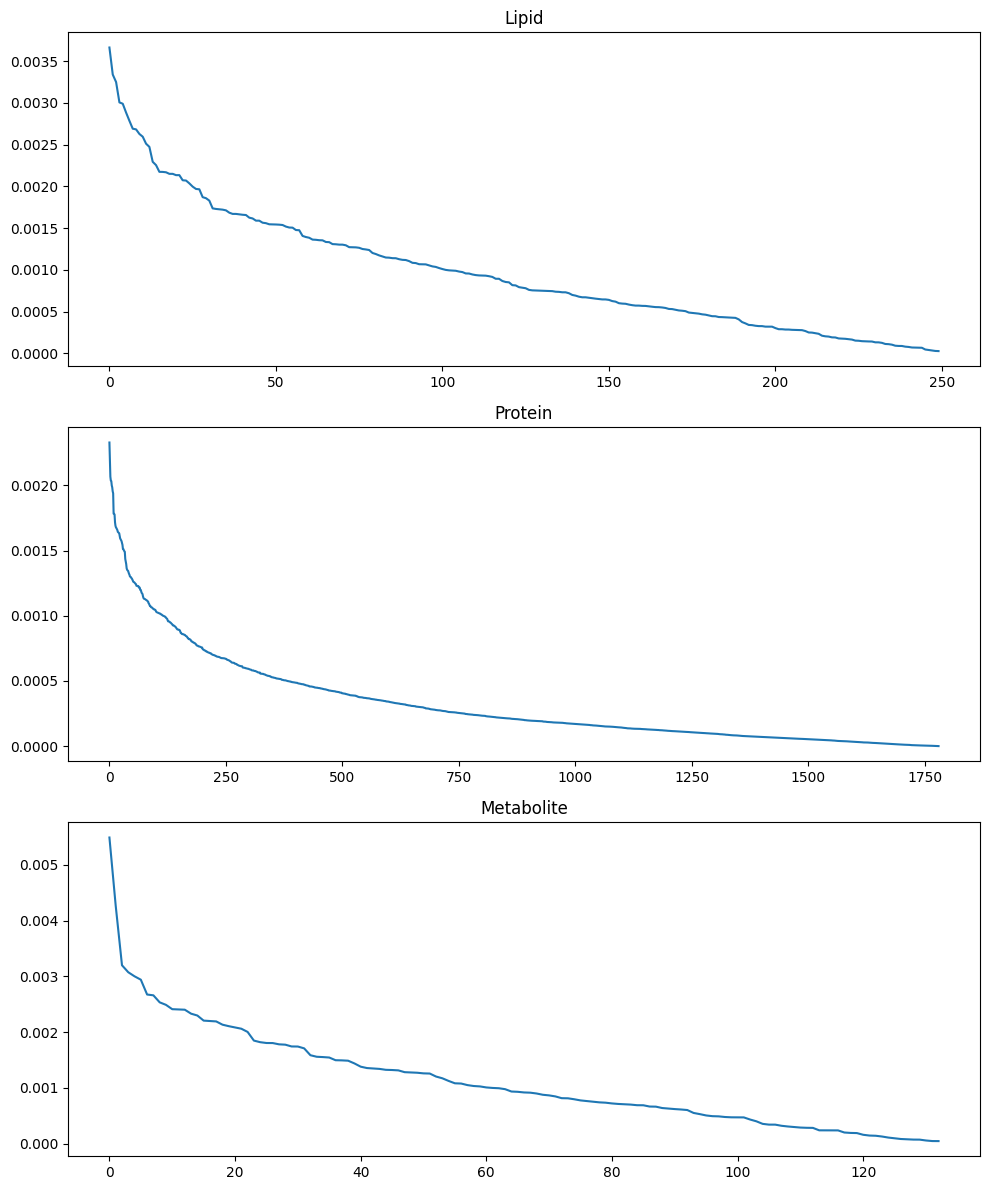

In [77]:
fig, axs = plt.subplots(3, 1, figsize = (10, 12))
axs[0].plot(sorted(abs_lip_scores, reverse = True))
axs[1].plot(sorted(abs_pro_scores, reverse = True))
axs[2].plot(sorted(abs_metab_scores, reverse = True))

axs[0].set_title('Lipid')
axs[1].set_title('Protein')
axs[2].set_title('Metabolite')

plt.tight_layout()

## Testing the stability of integrated gradients across random baselines

In [78]:
lip_ranks = {}
pro_ranks = {}
metab_ranks = {}

for k in range(50):
    lip_baseline = -torch.rand_like(liptest_pos)/2# *2*liptest_pos.std().numpy() + liptest_pos.mean().numpy()
    pro_baseline = -torch.rand_like(protest_pos)/2# *2*protest_pos.std().numpy() + protest_pos.mean().numpy()
    metab_baseline = -torch.rand_like(metabtest_pos)/2# *2*metabtest_pos.std().numpy() + metabtest_pos.mean().numpy()

    lip_int_scores, metab_int_scores, pro_int_scores = integrated_grads(
        [liptest_pos, metabtest_pos, protest_pos], 
        [lip_baseline, metab_baseline, pro_baseline], 
        joint_model, n_steps = 100, class_idx = 1
    )

    lip_argsort = (-lip_int_scores.abs().sum(axis = 0)).argsort()
    pro_argsort = (-pro_int_scores.abs().sum(axis = 0)).argsort()
    metab_argsort = (-metab_int_scores.abs().sum(axis = 0)).argsort()

    for r, i in enumerate(lip_argsort.numpy()):
        lip_ranks.setdefault(i, []).append(r)
    
    for r, i in enumerate(pro_argsort.numpy()):
        pro_ranks.setdefault(i, []).append(r)

    for r, i in enumerate(metab_argsort.numpy()):
        metab_ranks.setdefault(i, []).append(r)

In [79]:
lip_mu_std = {k: (np.mean(v), np.std(v)) for k, v in lip_ranks.items()}
pro_mu_std = {k: (np.mean(v), np.std(v)) for k, v in pro_ranks.items()}
metab_mu_std = {k: (np.mean(v), np.std(v)) for k, v in metab_ranks.items()}

In [80]:
# sort lip_mu_std by the std
sorted(lip_mu_std.items(), key = lambda x: x[1][0], reverse = False)[:10]

[(236, (2.04, 2.106751053162191)),
 (3, (2.4, 3.435112807463533)),
 (204, (3.04, 2.0972362766269326)),
 (60, (4.54, 3.353863443850987)),
 (101, (5.08, 4.594953753847801)),
 (243, (7.78, 4.622942785715609)),
 (64, (9.82, 9.16447488948494)),
 (45, (11.14, 9.877266828429818)),
 (57, (12.04, 7.461796030447362)),
 (38, (14.32, 8.83275721391684))]

In [81]:
sorted(pro_mu_std.items(), key = lambda x: x[1][1], reverse = False)[:10]

[(1445, (2.52, 1.8787229705307806)),
 (1733, (2.0, 2.227105745132009)),
 (501, (3.48, 2.4595934623429137)),
 (1512, (2.16, 2.6257189491642094)),
 (1616, (7.64, 4.227339588914049)),
 (482, (3.98, 4.527648396242799)),
 (1434, (8.38, 4.787024127785445)),
 (1002, (1758.76, 4.8313973134073755)),
 (1609, (11.72, 5.440735244431583)),
 (991, (12.1, 5.748912940721924))]

In [82]:
sorted(metab_mu_std.items(), key = lambda x: x[1][1], reverse = False)[:10]

[(46, (0.18, 0.4331281565541544)),
 (132, (1.92, 1.1106754701531856)),
 (124, (1.56, 1.1516944039110375)),
 (19, (129.64, 1.5969971822141704)),
 (31, (5.16, 2.309632005320328)),
 (13, (128.32, 2.6187019685332653)),
 (102, (127.72, 2.856851413707055)),
 (6, (127.66, 2.9024816967553817)),
 (129, (104.98, 2.908539152220578)),
 (4, (122.7, 3.125699921617557))]

# Train on TCGA

The TCGA dataset was processed as in (Lee and van der Schaar, 2021).  The features are kernel-PCA representations of the
TCGA gene expression data.  The labels are the 1 year mortality status of the patients.

In [6]:
# load pre-processed tcga data
tcgadata = np.load('/Users/clab683/Documents/Data/tcga/multi_omics_1yr_mortality.npz')

In [7]:
rnaseq = torch.tensor(tcgadata['mRNAseq']).float()
methyl = torch.tensor(tcgadata['Methylation']).float()
mirna = torch.tensor(tcgadata['miRNAseq']).float()
rppa = torch.tensor(tcgadata['RPPA']).float()
labels = torch.tensor(tcgadata['label']).reshape(-1).long()

# sample train indices
train_inds = np.random.choice(len(rnaseq), size=int(len(rnaseq) * 0.7), replace=False)
valid_inds = np.setdiff1d(np.arange(len(rnaseq)), train_inds)
test_inds = np.random.choice(valid_inds, size=int(len(valid_inds) * 0.5), replace=False)
valid_inds = np.setdiff1d(valid_inds, test_inds)

# create train, valid, and test tensors
rnaseq_train = rnaseq[train_inds]
methyl_train = methyl[train_inds]
mirna_train = mirna[train_inds]
rppa_train = rppa[train_inds]
labels_train = labels[train_inds]

rnaseq_valid = rnaseq[valid_inds]
methyl_valid = methyl[valid_inds]
mirna_valid = mirna[valid_inds]
rppa_valid = rppa[valid_inds]
labels_valid = labels[valid_inds]

rnaseq_test = rnaseq[test_inds]
methyl_test = methyl[test_inds]
mirna_test = mirna[test_inds]
rppa_test = rppa[test_inds]
labels_test = labels[test_inds]

# dataloaders
train_dataset = torch.utils.data.TensorDataset(rnaseq_train, methyl_train, mirna_train, rppa_train, labels_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = torch.utils.data.TensorDataset(rnaseq_valid, methyl_valid, mirna_valid, rppa_valid, labels_valid)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=32, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(rnaseq_test, methyl_test, mirna_test, rppa_test, labels_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

### Build the model

In [20]:
# reload these modules with sys and importlib
import sys
import importlib

# import the modules
importlib.reload(sys.modules['models.multi_mlp'])
from models.multi_mlp import simple_FC, JointMLP

# three view-specific encoders with the appropriate input size:
marg_model = simple_FC(input_size=100, hidden_sizes=[256, 256], prediction_dim=labels.unique().size()[0])

# joint model
joint_model = JointMLP(marginal_models=[copy.deepcopy(marg_model) for _ in range(4)], hidden_dim=128)

# define optimizer
optimizer = AdamW(joint_model.parameters(), lr=1e-4)

## Training

To facilitate training, we need to group samples into sub-batches with similar view-missing patterns.  In a single batch, there may be several sub-batches that we feed through the model one by one.  We accumulate the loss over these sub-batches and update the gradients one all sub-batches have been passed forward.

The classes are heavily imbalanced, about 80% of patients survive to 1 year.  I use a class-balanced focal loss to address this issue.

In [21]:
# a function to build batches that group together batches of samples with the same view-missing patterns
def build_combo_batches(views):
    num_view_missing = []

    for view in views:
        na_views = torch.isnan(view).sum(axis = 1) > 0
        num_view_missing.append(na_views)

    which_na = torch.stack(num_view_missing, axis = 1)

    input_dict = {}
    gt_dict = {}

    comb = torch.unique(which_na, dim = 0)[0]
    which_na == comb.unsqueeze(0)

    for comb in torch.unique(which_na, dim = 0):
        inds = (which_na == comb.unsqueeze(0)).all(axis = 1)
        input_batch = [views[i][inds] if not comb[i] else None for i in range(len(views))]

        gt_dict[comb] = y[inds]
        input_dict[comb] = input_batch

    return input_dict, gt_dict

In [22]:
# handle class imbalance
alpha = torch.tensor([1/0.9391, 1/0.1609])
# focal constant 
gamma = 3

for epoch in range(40):
    accumulate_loss = []
    for idx, batch in enumerate(train_loader):
        x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
        views = x_rnaseq, x_methyl, x_mirna, x_clinical

        input_dict, gt_dict = build_combo_batches(views)

        loss = 0
        for comb, x in input_dict.items():
            y_gt = gt_dict[comb]
            yhat, h, yhats, hiddens = joint_model(x)
            # pass alpha and gamma to do focal loss
            tmp_loss = joint_model.loss(y_gt, yhat, yhats, alpha = alpha, gamma = gamma)
            loss += tmp_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(joint_model.parameters(), 2.0)
        optimizer.step()

        if idx % 50 == 0 and idx != 0:
            print(loss.item())

        accumulate_loss.append(loss.item())

    joint_model.eval()
    allpreds = []
    all_gt = []
    
    for batch in valid_loader:
        x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
        views = [x_rnaseq, x_methyl, x_mirna, x_clinical]

        num_view_missing = []

        input_dict, gt_dict = build_combo_batches(views)

        for comb, x in input_dict.items():
            y_gt = gt_dict[comb]
            with torch.inference_mode():
                yhat, h, yhats, hiddens = joint_model(x)
            preds = yhat.argmax(axis = 1) == y_gt
            allpreds.extend(preds.tolist())
            all_gt.extend(y_gt.tolist())

    pred_1 = np.array(allpreds)[np.array(all_gt) == 1]
    pred_0 = np.array(allpreds)[np.array(all_gt) == 0]
        
    joint_model.train()
    print(f"Average loss for epoch {epoch} is {np.mean(accumulate_loss)}, validation accuracy: 0: {np.mean(pred_0)}, 1: {np.mean(pred_1)}")

4.007861614227295
3.7652010917663574
13.641897201538086
Average loss for epoch 0 is 6.278190279156907, validation accuracy: 0: 0.7937569676700111, 1: 0.4635416666666667
2.446101665496826
3.53220272064209
5.706995010375977
Average loss for epoch 1 is 4.9068848471971425, validation accuracy: 0: 0.7647714604236343, 1: 0.640625
5.413322925567627
3.0159261226654053
5.531422138214111
Average loss for epoch 2 is 4.20946019475565, validation accuracy: 0: 0.7614269788182831, 1: 0.6875
1.6291477680206299
3.5837631225585938
2.889500141143799
Average loss for epoch 3 is 4.277455176197508, validation accuracy: 0: 0.7447045707915273, 1: 0.7083333333333334
4.114343643188477
2.741544485092163
2.587074041366577
Average loss for epoch 4 is 3.507496753953538, validation accuracy: 0: 0.7536231884057971, 1: 0.7083333333333334
4.295334815979004
1.8289796113967896
2.619770050048828
Average loss for epoch 5 is 3.2579554709248573, validation accuracy: 0: 0.778149386845039, 1: 0.6666666666666666
2.5771746635437

## Evaluation on test set

In [23]:
joint_model.eval()
all_preds = []
all_gt = []
y_score = []

for batch in test_loader:
    x_rnaseq, x_methyl, x_mirna, x_clinical, y = batch
    views = [x_rnaseq, x_methyl, x_mirna, x_clinical]

    num_view_missing = []

    input_dict, gt_dict = build_combo_batches(views)

    for comb, x in input_dict.items():
        y_gt = gt_dict[comb]
        with torch.inference_mode():
            yhat, h, yhats, hiddens = joint_model(x)
        preds = yhat.argmax(axis = 1)
        all_preds.extend(preds.tolist())
        all_gt.extend(y_gt.tolist())
        y_score.extend(yhat[:, 1].tolist())

In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_gt, y_score)
auc(fpr, tpr)

0.8244845426187517

In [25]:
confusion_matrix(all_gt, all_preds)

array([[860,  57],
       [123,  49]])

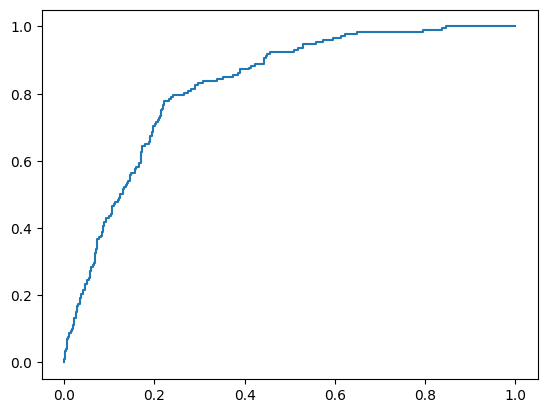

In [26]:
plt.plot(fpr, tpr)